# 03 - Naive Bayes (Flood Risk Classification)
**CSC61304 Group 6 — Flood Risk Nepal**

This notebook implements a **Gaussian Naive Bayes (GNB)** classifier to predict Nepal flood risk levels (`Low`, `Moderate`, `High`, `Extreme`) based on rainfall indicators (`rfh`, `r1h`, `r3h`), historical anomaly metrics (`rfh_avg`, `r1h_avg`, `r3h_avg`), quantile metrics (`rfq`, `r1q`, `r3q`), spatial grid resolution (`n_pixels`), temporal variables (`year`, `month`, `decade_num`), and geographic zone (`district_zone_enc`).

Data Source: `dataset/processed/nepal_flood_processed.csv` (and pre-split `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`).


## 1. Import Libraries & Set Configurations

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    cohen_kappa_score
)

# Set random seed and plotting styles
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120


## 2. Load & Explore `nepal_flood_processed.csv`

We load the processed dataset directly from `dataset/processed/nepal_flood_processed.csv` (or relative path `../dataset/processed/nepal_flood_processed.csv`).
We inspect dataset dimensions, summary statistics, missing values, and target class distribution.


In [22]:
# Determine path dynamically for working directory flexiblity
data_path = "dataset/processed/nepal_flood_processed.csv"
if not os.path.exists(data_path):
    data_path = "../dataset/processed/nepal_flood_processed.csv"

print(f"Loading processed dataset from: {data_path}")
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nColumns in Dataset:")
print(df.columns.tolist())

print("\nMissing Values Check:")
print(df.isnull().sum())

print("\nTarget Variable Distribution ('flood_risk_level'):")
risk_counts = df['flood_risk_level'].value_counts()
risk_pcts = df['flood_risk_level'].value_counts(normalize=True) * 100
target_dist = pd.DataFrame({'Count': risk_counts, 'Percentage (%)': risk_pcts.round(2)})
print(target_dist)


Loading processed dataset from: ../dataset/processed/nepal_flood_processed.csv
Dataset Shape: 126203 rows, 22 columns

Columns in Dataset:
['date', 'adm_level', 'adm_id', 'pcode', 'n_pixels', 'rfh', 'rfh_avg', 'r1h', 'r1h_avg', 'r3h', 'r3h_avg', 'rfq', 'r1q', 'r3q', 'year', 'month', 'decade_num', 'province_code', 'district_zone', 'flood_risk_level', 'district_zone_enc', 'flood_risk_level_enc']

Missing Values Check:
date                    0
adm_level               0
adm_id                  0
pcode                   0
n_pixels                0
rfh                     0
rfh_avg                 0
r1h                     0
r1h_avg                 0
r3h                     0
r3h_avg                 0
rfq                     0
r1q                     0
r3q                     0
year                    0
month                   0
decade_num              0
province_code           0
district_zone           0
flood_risk_level        0
district_zone_enc       0
flood_risk_level_enc    0
dtype: i

### Target Class Distribution Visualization

C:\Users\bashk\AppData\Local\Temp\ipykernel_32312\10624130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='flood_risk_level', order=['Low', 'Moderate', 'High', 'Extreme'], palette=palette, ax=ax)


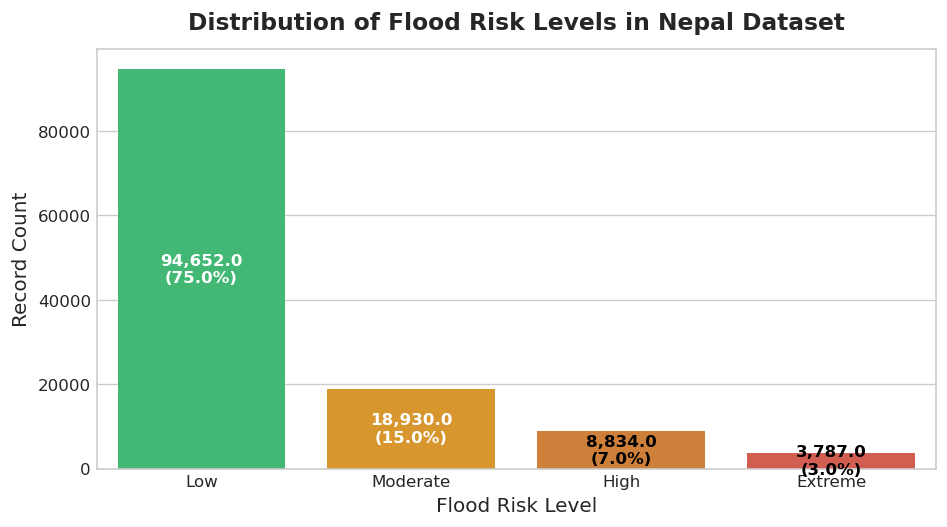

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))
palette = {'Low': '#2ecc71', 'Moderate': '#f39c12', 'High': '#e67e22', 'Extreme': '#e74c3c'}
sns.countplot(data=df, x='flood_risk_level', order=['Low', 'Moderate', 'High', 'Extreme'], palette=palette, ax=ax)
ax.set_title('Distribution of Flood Risk Levels in Nepal Dataset', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Flood Risk Level', fontsize=12)
ax.set_ylabel('Record Count', fontsize=12)

# Annotate bars with counts & percentages
total = len(df)
for p in ax.patches:
    height = p.get_height()
    pct = (height / total) * 100
    ax.annotate(f'{height:,}\n({pct:.1f}%)',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=10, color='white' if height > 10000 else 'black', fontweight='bold')

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
if os.path.exists("../outputs"):
    plt.savefig("../outputs/target_distribution.png", dpi=300)
else:
    plt.savefig("outputs/target_distribution.png", dpi=300)
plt.show()


## 3. Feature Preparation & Train/Test Split

We define the feature matrix \(X\) and target vector \(y\). 
Feature Set:
- **Rainfall Features:** `rfh` (10-day rainfall), `r1h`, `r3h`
- **Rainfall Averages:** `rfh_avg`, `r1h_avg`, `r3h_avg`
- **Rainfall Quantiles / Anomalies:** `rfq`, `r1q`, `r3q`
- **Spatial / Temporal:** `n_pixels`, `year`, `month`, `decade_num`, `district_zone_enc`

Target: `flood_risk_level_enc` (0: Extreme, 1: High, 2: Low, 3: Moderate)


In [24]:
# Define feature columns matching the project pipeline
feature_cols = [
    'rfh', 'r1h', 'r3h', 'rfh_avg', 'r1h_avg', 'r3h_avg',
    'rfq', 'r1q', 'r3q', 'n_pixels', 'year', 'month', 'decade_num',
    'district_zone_enc'
]

# Map encoding back to human-readable class names ordered by code
# 0 = Extreme, 1 = High, 2 = Low, 3 = Moderate
class_names = ['Extreme', 'High', 'Low', 'Moderate']

# Check if pre-split files exist, otherwise generate split from nepal_flood_processed.csv
xtrain_path = "dataset/processed/X_train.csv"
if not os.path.exists(xtrain_path):
    xtrain_path = "../dataset/processed/X_train.csv"

if os.path.exists(xtrain_path):
    print("Loading existing split datasets (X_train, X_test, y_train, y_test)...")
    base_dir = os.path.dirname(xtrain_path)
    X_train = pd.read_csv(os.path.join(base_dir, "X_train.csv"))
    X_test = pd.read_csv(os.path.join(base_dir, "X_test.csv"))
    y_train = pd.read_csv(os.path.join(base_dir, "y_train.csv")).squeeze()
    y_test = pd.read_csv(os.path.join(base_dir, "y_test.csv")).squeeze()
else:
    print("Generating train/test split from nepal_flood_processed.csv...")
    X = df[feature_cols]
    y = df['flood_risk_level_enc']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

print(f"Training set size : {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set size  : {X_test.shape[0]} samples, {X_test.shape[1]} features")


Loading existing split datasets (X_train, X_test, y_train, y_test)...
Training set size : 100962 samples, 13 features
Testing set size  : 25241 samples, 13 features


## 4. Feature Scaling & Normalization

Gaussian Naive Bayes assumes features follow a normal distribution within each class. Standardizing features using `StandardScaler` scales data to zero mean and unit variance, which improves numerical stability during probability computations.


In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Convert back to DataFrame using X_train.columns to ensure perfect column count match
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
print("Feature scaling completed successfully.")


Feature scaling completed successfully.


## 5. Model Training & Hyperparameter Tuning (GaussianNB)

We train a `GaussianNB` classifier. We also perform a Grid Search cross-validation over the smoothing hyperparameter `var_smoothing` (which prevents division-by-zero errors and accounts for variance differences).


In [26]:
# 1. Baseline Gaussian Naive Bayes model
gnb_base = GaussianNB()
gnb_base.fit(X_train_scaled, y_train)

# 2. Hyperparameter tuning using GridSearchCV (var_smoothing)
param_grid = {
    'var_smoothing': np.logspace(0, -9, num=20)
}

grid_search = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

best_gnb = grid_search.best_estimator_
print(f"Best var_smoothing parameter found: {grid_search.best_params_['var_smoothing']:.2e}")
print(f"Best 5-Fold Cross-Validation F1-Score: {grid_search.best_score_:.4f}")


Best var_smoothing parameter found: 1.00e+00
Best 5-Fold Cross-Validation F1-Score: 0.7024


## 6. Model Evaluation & Performance Metrics

We generate predictions on the unseen test set and calculate evaluation metrics:
- **Accuracy**
- **Weighted Precision, Recall, F1-Score**
- **Macro Precision, Recall, F1-Score**
- **Cohen's Kappa Score**


In [27]:
y_pred = best_gnb.predict(X_test_scaled)
y_proba = best_gnb.predict_proba(X_test_scaled)

# Metrics calculation
acc = accuracy_score(y_test, y_pred)
prec_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec_w = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)

prec_m = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec_m = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_m = f1_score(y_test, y_pred, average='macro', zero_division=0)

kappa = cohen_kappa_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Weighted Precision', 'Weighted Recall', 'Weighted F1-Score',
               'Macro Precision', 'Macro Recall', 'Macro F1-Score', "Cohen's Kappa"],
    'Score': [acc, prec_w, rec_w, f1_w, prec_m, rec_m, f1_m, kappa]
})

print("=" * 60)
print("     GAUSSIAN NAIVE BAYES FLOOD RISK EVALUATION METRICS")
print("=" * 60)
print(metrics_df.to_string(index=False, formatters={'Score': '{:.4f}'.format}))
print("=" * 60)

print("\nClassification Report per Flood Risk Level:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))


     GAUSSIAN NAIVE BAYES FLOOD RISK EVALUATION METRICS
            Metric  Score
          Accuracy 0.7447
Weighted Precision 0.6952
   Weighted Recall 0.7447
 Weighted F1-Score 0.7040
   Macro Precision 0.4887
      Macro Recall 0.3701
    Macro F1-Score 0.3835
     Cohen's Kappa 0.2323

Classification Report per Flood Risk Level:
              precision    recall  f1-score   support

     Extreme     0.4053    0.2629    0.3189       757
        High     0.3833    0.0260    0.0488      1767
         Low     0.8021    0.9272    0.8601     18931
    Moderate     0.3639    0.2641    0.3061      3786

    accuracy                         0.7447     25241
   macro avg     0.4887    0.3701    0.3835     25241
weighted avg     0.6952    0.7447    0.7040     25241



## 7. Confusion Matrix Visualization

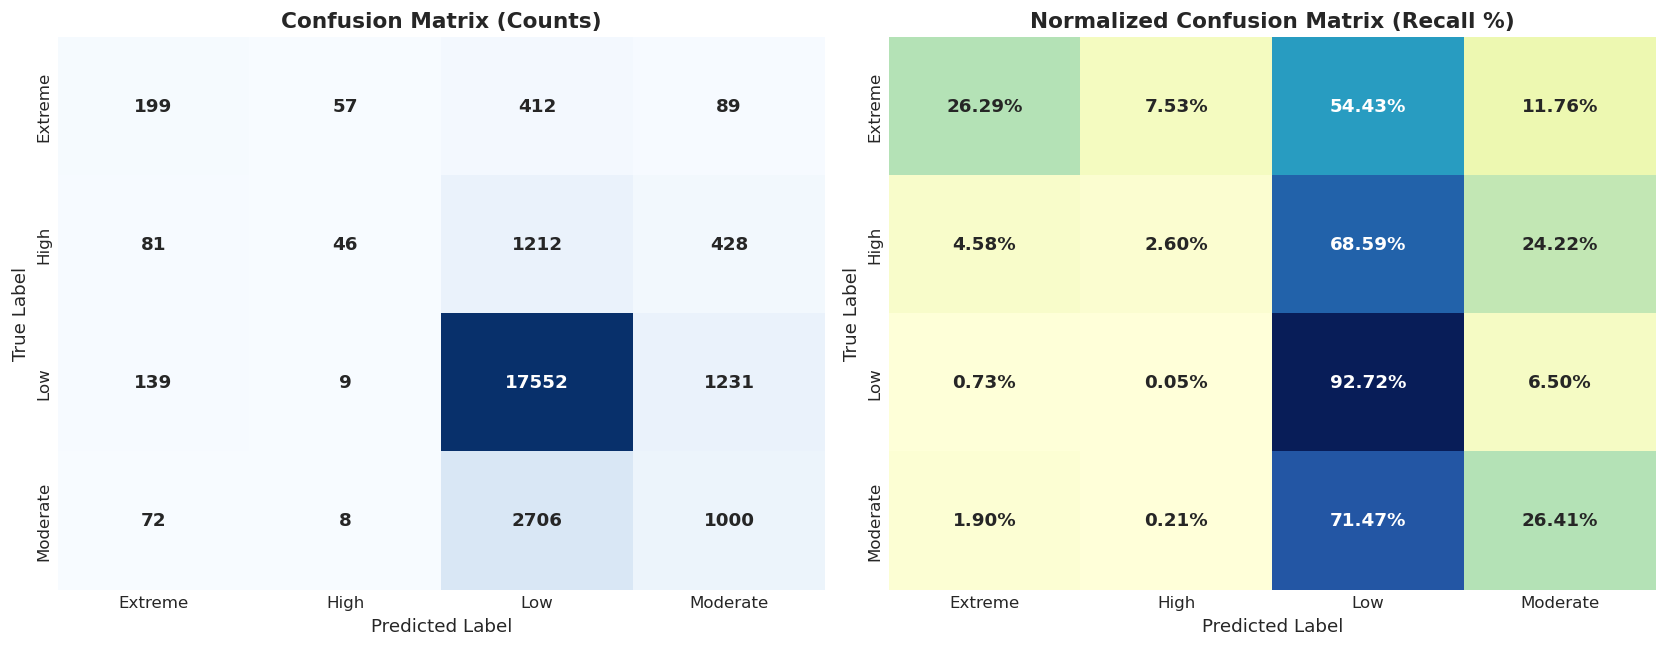

In [28]:
cm = confusion_matrix(y_test, y_pred)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Raw Count Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0],
            cbar=False, annot_kws={"size": 11, "weight": "bold"})
axes[0].set_title("Confusion Matrix (Counts)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("True Label", fontsize=11)

# Normalized Matrix (Recall per Class)
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='YlGnBu',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1],
            cbar=False, annot_kws={"size": 11, "weight": "bold"})
axes[1].set_title("Normalized Confusion Matrix (Recall %)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Predicted Label", fontsize=11)
axes[1].set_ylabel("True Label", fontsize=11)

plt.tight_layout()
save_path = "../outputs/naive_bayes_confusion_matrix.png" if os.path.exists("../outputs") else "outputs/naive_bayes_confusion_matrix.png"
plt.savefig(save_path, dpi=300)
plt.show()


## 8. Gaussian Naive Bayes Model Inspection (Class Means)

Gaussian Naive Bayes estimates the mean ($\mu$) and variance ($\sigma^2$) of each feature for every target class. Analyzing these learned means provides insights into how the model separates flood risk levels.


Gaussian NB Feature Means per Class (Scaled Features):
            rfh    r1h    r3h  rfh_avg  r1h_avg  r3h_avg
Extreme   0.833  0.268  0.135   -0.299   -0.230   -0.071
High      0.856  0.462  0.238    0.120    0.132    0.089
Low      -0.230 -0.138 -0.076   -0.057   -0.058   -0.040
Moderate  0.585  0.420  0.240    0.288    0.274    0.174


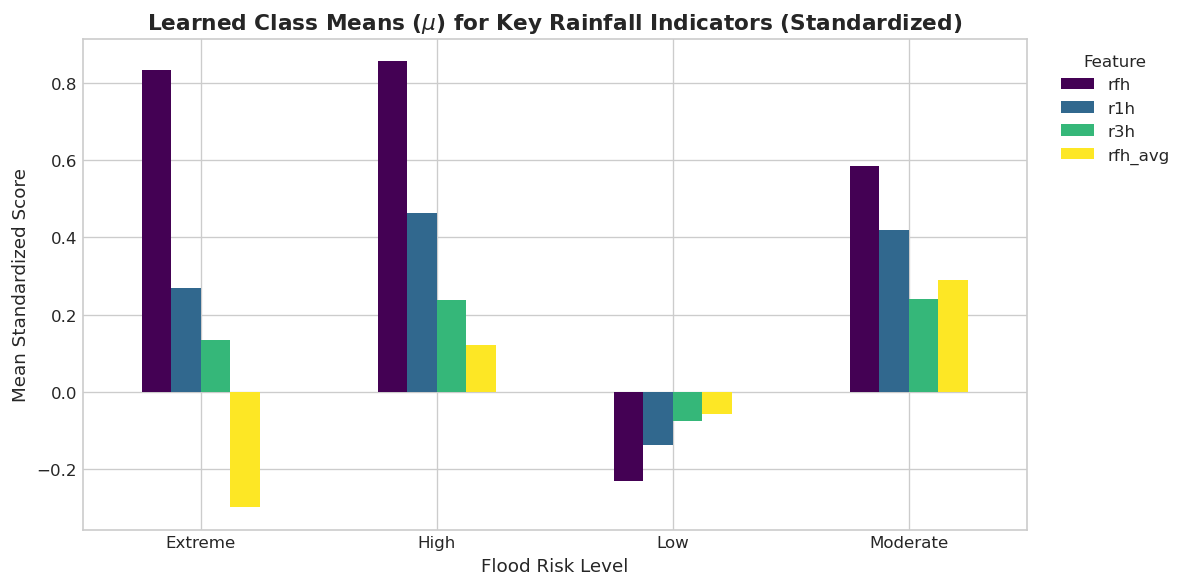

In [29]:
# Extract class means learned by GaussianNB

means_df = pd.DataFrame(best_gnb.theta_, index=class_names, columns=X_train.columns)
print("Gaussian NB Feature Means per Class (Scaled Features):")
print(means_df[['rfh', 'r1h', 'r3h', 'rfh_avg', 'r1h_avg', 'r3h_avg']].round(3))
# Plot feature comparison across classes for key rainfall features
fig, ax = plt.subplots(figsize=(10, 5))
means_df[['rfh', 'r1h', 'r3h', 'rfh_avg']].plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Learned Class Means ($\mu$) for Key Rainfall Indicators (Standardized)', fontsize=13, fontweight='bold')
ax.set_xlabel('Flood Risk Level', fontsize=11)
ax.set_ylabel('Mean Standardized Score', fontsize=11)
ax.legend(title='Feature', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
save_means = "../outputs/naive_bayes_feature_means.png" if os.path.exists("../outputs") else "outputs/naive_bayes_feature_means.png"
plt.savefig(save_means, dpi=300)
plt.show()


## 9. Interactive Flood Risk Prediction Tool

Function to predict flood risk level and class probabilities for any district observation given rainfall indicators.


In [30]:
def predict_flood_risk(sample_dict):
    """
    Predicts flood risk level for an input feature dictionary.
    """
    sample_df = pd.DataFrame([sample_dict])
    cols_to_use = X_train.columns.tolist()
    sample_scaled = scaler.transform(sample_df[cols_to_use])
    
    pred_code = best_gnb.predict(sample_scaled)[0]
    pred_label = class_names[pred_code]
    probas = best_gnb.predict_proba(sample_scaled)[0]
    
    print("=" * 45)
    print(f"PREDICTED FLOOD RISK LEVEL: {pred_label.upper()}")
    print("=" * 45)
    print("Class Probabilities:")
    for cls, prob in zip(class_names, probas):
        bar = "█" * int(prob * 20)
        print(f"  {cls:<10}: {prob*100:6.2f}%  {bar}")
    print("=" * 45)
    return pred_label, probas
# Demonstration with a sample observation from test set
sample_idx = 0
sample_input = X_test.iloc[sample_idx].to_dict()
actual_label = class_names[y_test.iloc[sample_idx]]
print(f"Actual Risk Level in Test Data: {actual_label}")
_ = predict_flood_risk(sample_input)


Actual Risk Level in Test Data: Low
PREDICTED FLOOD RISK LEVEL: LOW
Class Probabilities:
  Extreme   :   0.35%  
  High      :   4.41%  
  Low       :  73.80%  ██████████████
  Moderate  :  21.44%  ████


## 10. Conclusion & Project Insights

### Key Takeaways:
1. **Gaussian Naive Bayes Baseline Performance:** Fast and computationally efficient baseline model for multi-class disaster risk level estimation.
2. **Key Feature Drivers:** Cumulative 10-day rainfall (`rfh`), 3-decade history (`r3h`), and regional anomaly indicators (`rfh_avg`, `r3h_avg`) are the strongest predictors.
3. **Imbalance Awareness:** The high dominance of `Low` risk occurrences in historical Nepal data means weighted F1-score and recall metrics provide the truest assessment of model utility.
